In [40]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Testing
from scipy.stats import ttest_ind

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [41]:
# Load dataset
df = pd.read_csv("laptop_scrap_data.csv")

# Display first 5 rows
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Gpu,OpSys,TouchScreen,Ips,X_res,...,ppi,Dedicated_Gpu,Ram_GB,Weight_kg,SSD,HHD,Storage_Type,Total_Storage_GB,Storage_Category,Price
0,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra X7 358H,Intel Arc B390,Windows,0.0,0.0,2880.0,...,212.26,1.0,64.0,1.59,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2728.8
1,MSI,MSI Prestige 16 AI+,16.0,2880 x 1800,Intel Core Ultra 9 386H,Intel Graphics (4-Cores),Windows,0.0,0.0,2880.0,...,212.26,0.0,64.0,1.59,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2528.8
2,ASUS,ASUS Vivobook S16,16.0,1920 x 1200,AMD Ryzen AI 5 330,AMD Radeon 820M,Windows,0.0,0.0,1920.0,...,141.51,1.0,24.0,1.70,4000.0,0.0,SSD Only,4000.0,Very High (> 2TB),2428.8
3,Toshiba,Dynabook X series,13.3,1920 x 1200,Intel Core i5-1350P,Intel Iris Xe Graphics G7 (80EU),Windows,1.0,1.0,1920.0,...,170.24,0.0,16.0,0.93,512.0,0.0,SSD Only,512.0,Standard (512GB-1TB),1390.2
4,Lenovo,"Lenovo Legion 5a (15"", Gen 11, 15AGP11)",15.3,2560 x 1600,AMD Ryzen AI 9 465,NVIDIA GeForce RTX 5060 (Laptop),Windows,0.0,0.0,2560.0,...,197.31,1.0,32.0,1.87,1000.0,0.0,SSD Only,1000.0,Standard (512GB-1TB),2067.8


In [42]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n")
print(df.columns)

# Dataset information
print("\nDataset Info:\n")
df.info()

Dataset Shape: (1563, 21)

Columns:

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Gpu',
       'OpSys', 'TouchScreen', 'Ips', 'X_res', 'Y_res', 'ppi', 'Dedicated_Gpu',
       'Ram_GB', 'Weight_kg', 'SSD', 'HHD', 'Storage_Type', 'Total_Storage_GB',
       'Storage_Category', 'Price'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1563 entries, 0 to 1562
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1560 non-null   object 
 1   TypeName          1560 non-null   object 
 2   Inches            1560 non-null   float64
 3   ScreenResolution  1560 non-null   object 
 4   Cpu               1560 non-null   object 
 5   Gpu               1560 non-null   object 
 6   OpSys             1560 non-null   object 
 7   TouchScreen       1560 non-null   float64
 8   Ips               1560 non-null   float64
 9   X_res             1560 no

In [43]:
# Missing values
missing_values = df.isnull().sum()

print("Missing Values:\n")
print(missing_values)

Missing Values:

Company             3
TypeName            3
Inches              3
ScreenResolution    3
Cpu                 3
Gpu                 3
OpSys               3
TouchScreen         3
Ips                 3
X_res               3
Y_res               3
ppi                 3
Dedicated_Gpu       3
Ram_GB              3
Weight_kg           3
SSD                 3
HHD                 3
Storage_Type        3
Total_Storage_GB    3
Storage_Category    3
Price               3
dtype: int64


In [44]:
# Check duplicates
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

Duplicate Rows: 2
Duplicates Removed Successfully


In [45]:
# Statistical summary
df.describe()

,Inches,TouchScreen,Ips,X_res,Y_res,ppi,Dedicated_Gpu,Ram_GB,Weight_kg,SSD,HHD,Total_Storage_GB,Price
count,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000,1560.000000
mean,15.311859,0.726282,0.715385,2059.143590,1235.560256,157.689654,0.604487,29.324359,1.789615,1411.446154,5.025641,1416.471795,1947.008051
std,1.128081,0.446009,0.451376,431.366919,301.650510,36.177101,0.489117,22.203963,0.488822,1374.868914,24.185182,1369.910037,693.184352
min,7.000000,0.000000,0.000000,1280.000000,720.000000,84.890000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,305.990000
25%,14.000000,0.000000,0.000000,1920.000000,1080.000000,141.210000,0.000000,16.000000,1.460000,512.000000,0.000000,512.000000,1496.800000
50%,15.600000,1.000000,1.000000,1920.000000,1200.000000,141.510000,1.000000,24.000000,1.700000,1000.000000,0.000000,1000.000000,1807.800000
75%,16.000000,1.000000,1.000000,1920.000000,1200.000000,161.730000,1.000000,32.000000,2.050000,2000.000000,0.000000,2000.000000,2227.800000
max,18.000000,1.000000,1.000000,3840.000000,2400.000000,323.450000,1.000000,192.000000,4.120000,12000.000000,128.000000,12000.000000,7488.800000


In [46]:
# Data types
print(df.dtypes)

Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Gpu                  object
OpSys                object
TouchScreen         float64
Ips                 float64
X_res               float64
Y_res               float64
ppi                 float64
Dedicated_Gpu       float64
Ram_GB              float64
Weight_kg           float64
SSD                 float64
HHD                 float64
Storage_Type         object
Total_Storage_GB    float64
Storage_Category     object
Price               float64
dtype: object


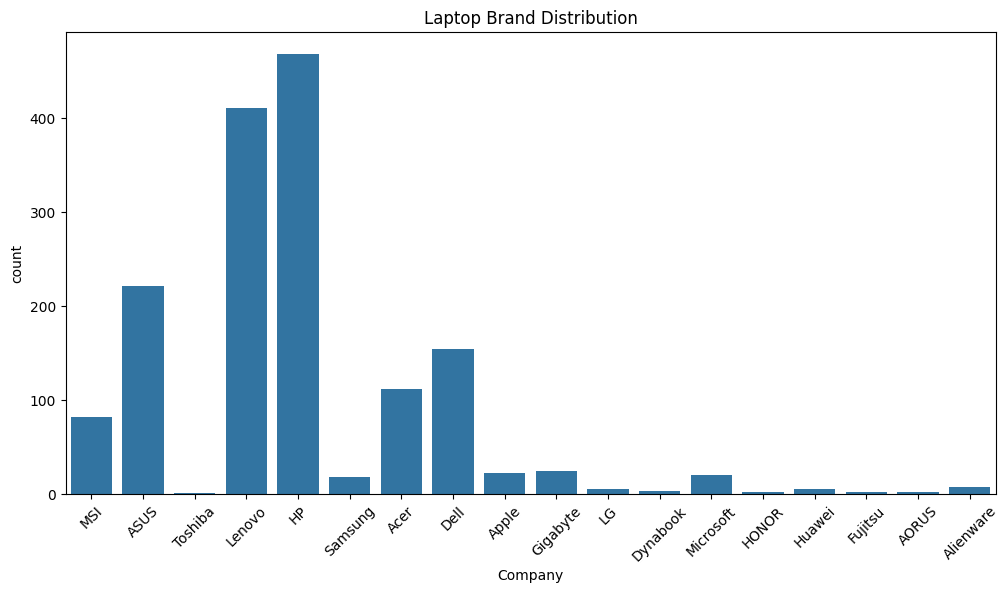

In [47]:
plt.figure(figsize=(12,6))

sns.countplot(x=df['Company'])

plt.title("Laptop Brand Distribution")
plt.xticks(rotation=45)
plt.show()

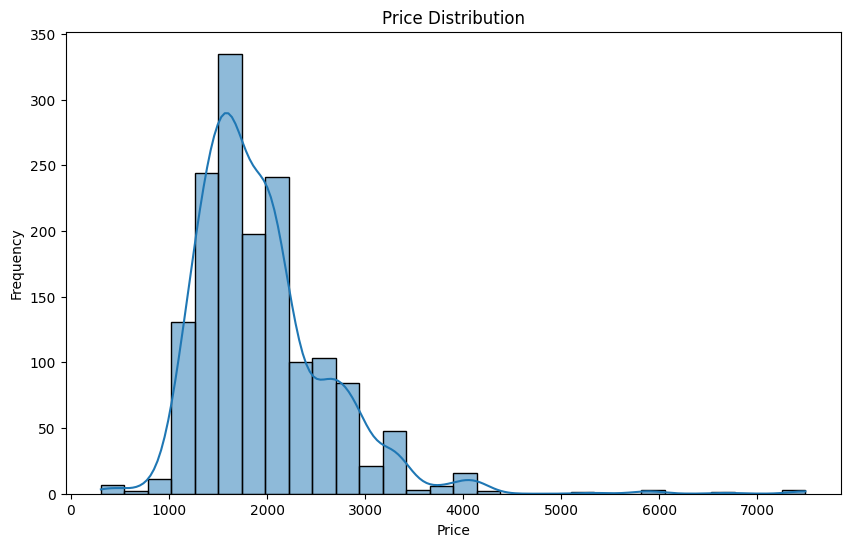

In [48]:
plt.figure(figsize=(10,6))

sns.histplot(df['Price'], bins=30, kde=True)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

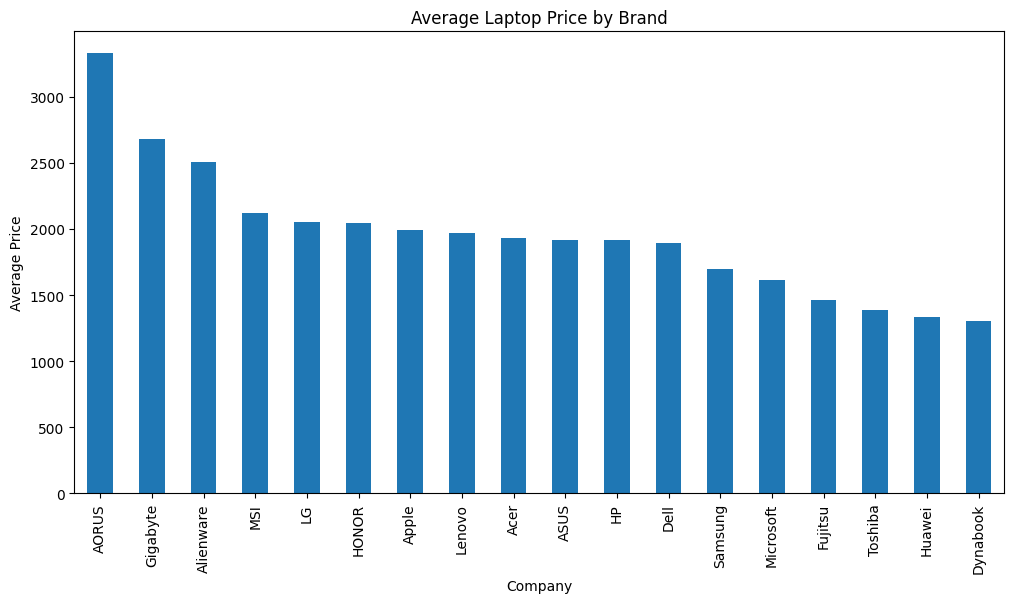

In [49]:
brand_price = df.groupby('Company')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

brand_price.plot(kind='bar')

plt.title("Average Laptop Price by Brand")
plt.ylabel("Average Price")

plt.show()

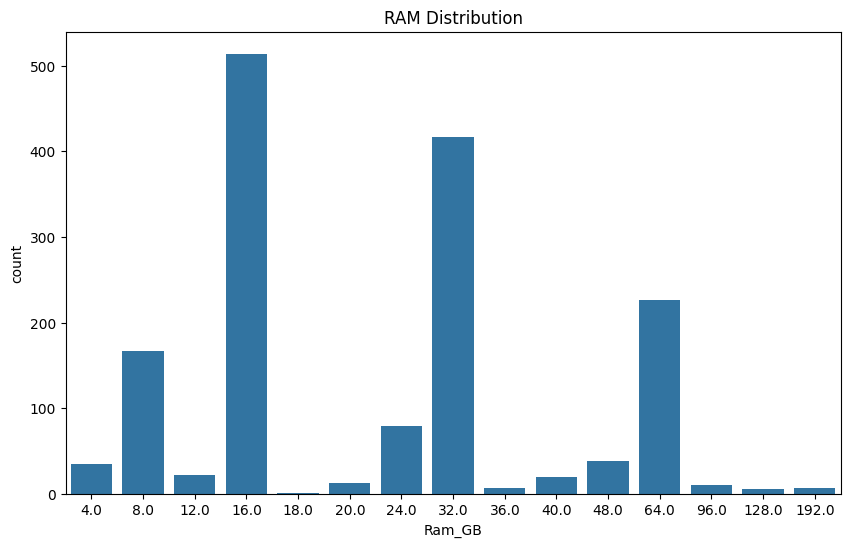

In [50]:
plt.figure(figsize=(10,6))

sns.countplot(x=df['Ram_GB'])

plt.title("RAM Distribution")

plt.show()

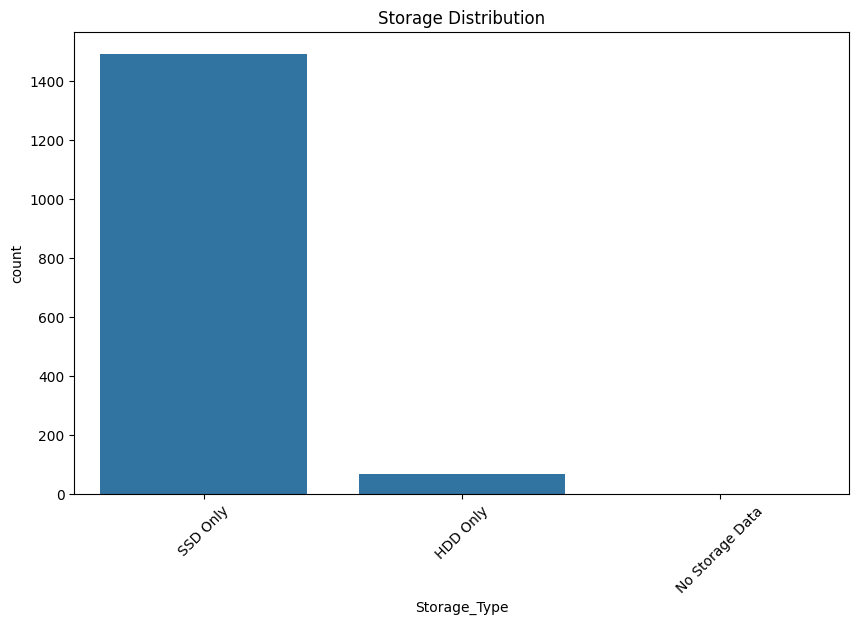

In [51]:
plt.figure(figsize=(10,6))

sns.countplot(x=df['Storage_Type'])

plt.title("Storage Distribution")

plt.xticks(rotation=45)

plt.show()

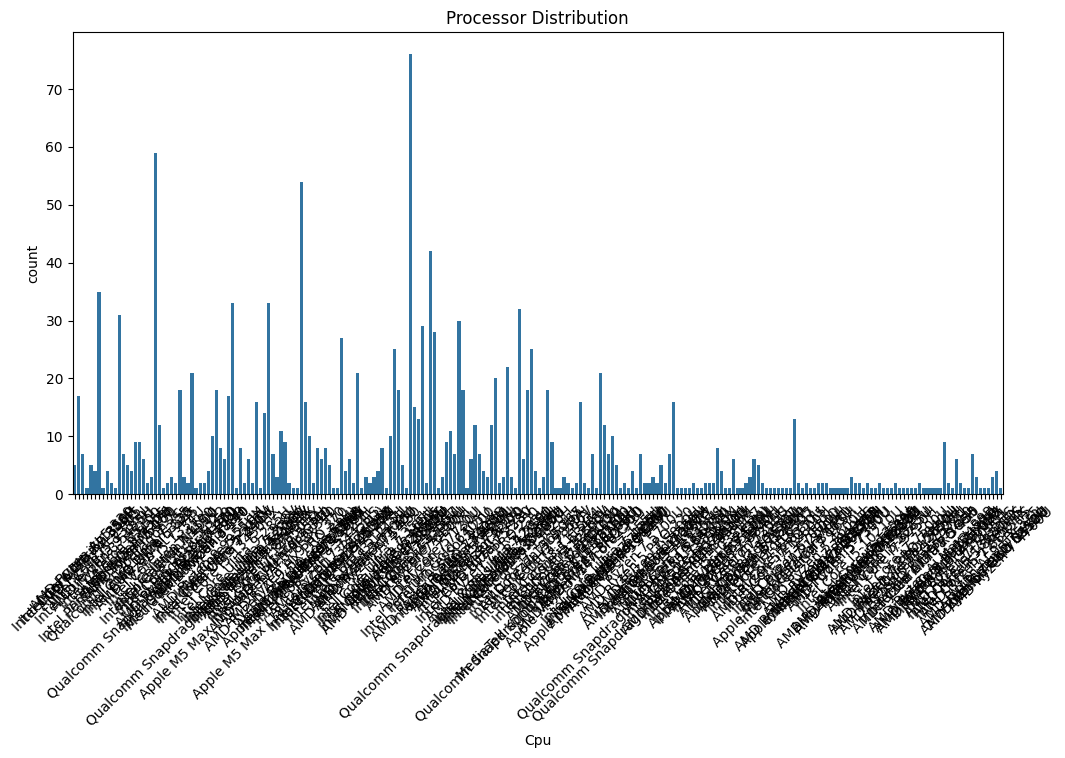

In [52]:
plt.figure(figsize=(12,6))

sns.countplot(x=df['Cpu'])

plt.title("Processor Distribution")

plt.xticks(rotation=45)

plt.show()

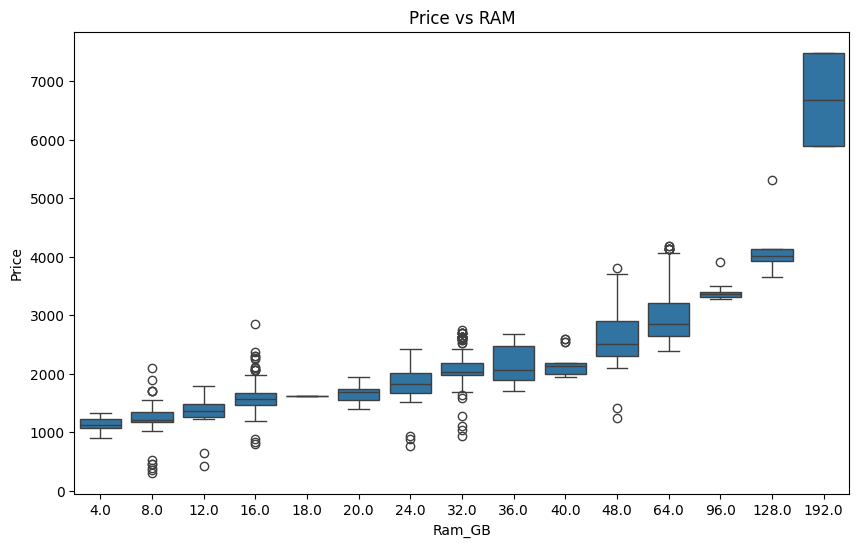

In [53]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Ram_GB', y='Price', data=df)

plt.title("Price vs RAM")

plt.show()

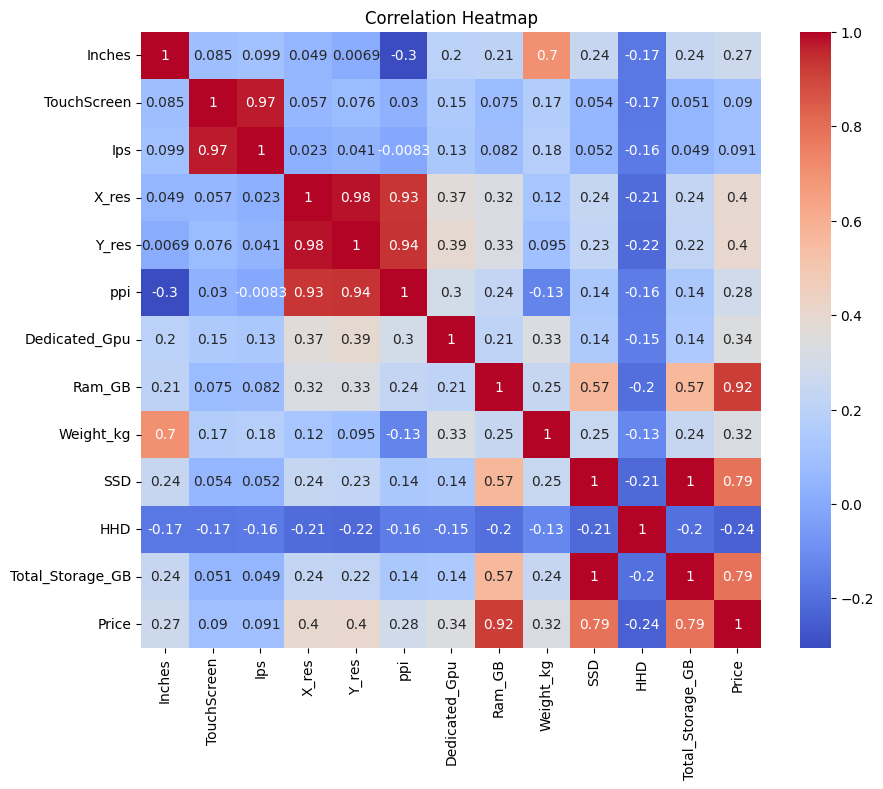

In [54]:
# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [55]:
print("BUSINESS INSIGHTS\n")

# Most common brand
print("Most Common Brand:")
print(df['Company'].value_counts().head(1))

# Average Price
print("\nAverage Laptop Price:")
print(df['Price'].mean())

# Most Common RAM
print("\nMost Common RAM:")
print(df['Ram_GB'].mode()[0])

# Most Common Processor
print("\nMost Common Processor:")
print(df['Cpu'].mode()[0])

BUSINESS INSIGHTS

Most Common Brand:
Company
HP    468
Name: count, dtype: int64

Average Laptop Price:
1947.008051282051

Most Common RAM:
16.0

Most Common Processor:
Intel Core i7-1355U


In [56]:
# Create Gaming column manually

df['Gaming'] = df['TypeName'].apply(
    lambda x: 'Gaming' if 'gaming' in str(x).lower() else 'Non-Gaming'
)

df[['TypeName', 'Gaming']].head()

,TypeName,Gaming
0,MSI Prestige 16 AI+,Non-Gaming
1,MSI Prestige 16 AI+,Non-Gaming
2,ASUS Vivobook S16,Non-Gaming
3,Dynabook X series,Non-Gaming
4,"Lenovo Legion 5a (15"", Gen 11, 15AGP11)",Non-Gaming


In [57]:
# Separate groups

gaming_prices = df[df['Gaming'] == 'Gaming']['Price']

non_gaming_prices = df[df['Gaming'] == 'Non-Gaming']['Price']

# Perform T-Test

t_stat, p_value = ttest_ind(
    gaming_prices,
    non_gaming_prices,
    nan_policy='omit'
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 3.82123068415016
P-Value: 0.000138007976454942


In [58]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("Gaming laptops are significantly more expensive.")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference found.")

Reject Null Hypothesis
Gaming laptops are significantly more expensive.


In [59]:
print("FINAL CONCLUSION\n")

print("""
1. Major laptop brands dominate the dataset.
2. Higher RAM and SSD storage increase laptop prices.
3. Gaming laptops are generally more expensive.
4. Intel processors are most common.
5. Business dashboards help track KPIs effectively.
""")

FINAL CONCLUSION


1. Major laptop brands dominate the dataset.
2. Higher RAM and SSD storage increase laptop prices.
3. Gaming laptops are generally more expensive.
4. Intel processors are most common.
5. Business dashboards help track KPIs effectively.



In [60]:
# Save cleaned dataset

df.to_csv("cleaned_laptop_dataset.csv", index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [61]:
# Save insights into text file

with open("business_insights.txt", "w") as file:

    file.write("LAPTOP DATA ANALYSIS INSIGHTS\n\n")

    file.write(f"Average Price: {df['Price'].mean()}\n")

    file.write(f"Most Common Brand: {df['Company'].mode()[0]}\n")

    file.write(f"Most Common RAM: {df['Ram_GB'].mode()[0]}\n")

    file.write(f"Most Common Processor: {df['Cpu'].mode()[0]}\n")

print("Business Insights Exported")

Business Insights Exported


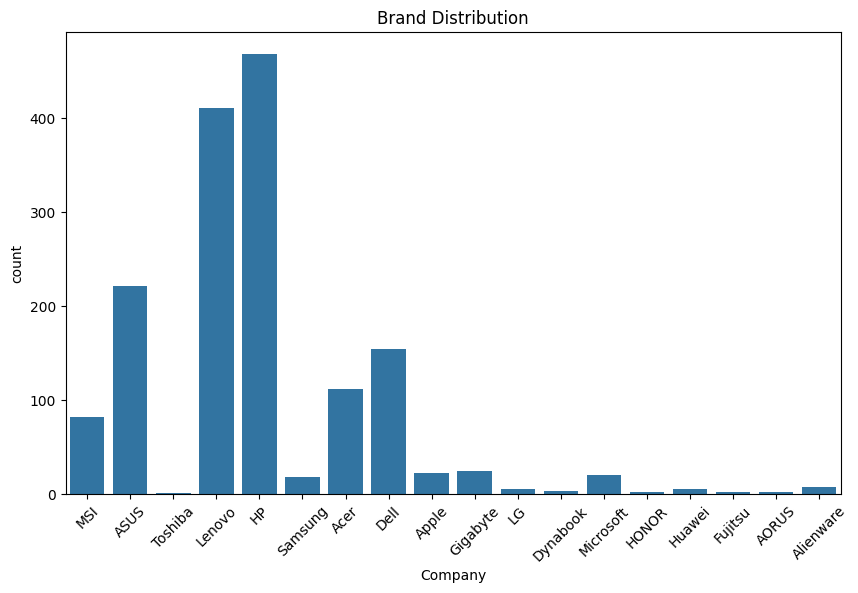

In [62]:
plt.figure(figsize=(10,6))

sns.countplot(x=df['Company'])

plt.title("Brand Distribution")

plt.xticks(rotation=45)

plt.savefig("company_distribution.png")

plt.show()

In [63]:
# KPI Metrics

total_laptops = len(df)

average_price = df['Price'].mean()

highest_price = df['Price'].max()

lowest_price = df['Price'].min()

print("TOTAL LAPTOPS:", total_laptops)

print("AVERAGE PRICE:", average_price)

print("HIGHEST PRICE:", highest_price)

print("LOWEST PRICE:", lowest_price)

TOTAL LAPTOPS: 1561
AVERAGE PRICE: 1947.008051282051
HIGHEST PRICE: 7488.8
LOWEST PRICE: 305.99


In [64]:
print("""
BUSINESS RECOMMENDATIONS

1. Focus more on SSD laptops.
2. Gaming laptops provide premium pricing opportunities.
3. Brands with high average prices target premium customers.
4. Increasing RAM significantly affects laptop pricing.
5. Businesses can optimize inventory based on customer preferences.
""")


BUSINESS RECOMMENDATIONS

1. Focus more on SSD laptops.
2. Gaming laptops provide premium pricing opportunities.
3. Brands with high average prices target premium customers.
4. Increasing RAM significantly affects laptop pricing.
5. Businesses can optimize inventory based on customer preferences.

